4개의 CSV 파일은 런타임으로 저장 후 사용하였음을 미리 알린다.

In [4]:
# Section 1

import pandas as pd

pitchers_npb = pd.read_csv('pitchers_npb.csv')
hitters_npb = pd.read_csv('hitters_npb.csv')

# 이닝 수 조정
def convert_innings(val):
    if pd.isna(val):
        return None
    whole = int(val)
    frac = round(val - whole, 1)  # 소수점 첫째 자리만 확인
    if frac == 0.1:   # 1/3
        return whole + 1/3
    elif frac == 0.2: # 2/3
        return whole + 2/3
    else:
        return val  # 나머지는 그대로

pitchers_npb['投球回'] = pitchers_npb['投球回'].apply(convert_innings)

# 이닝 수 기준으로 필터링
pitchers_npb_filtered = pitchers_npb[pitchers_npb['投球回'] >= 20]
print(pitchers_npb_filtered.shape)

# 타석 수 기준으로 필터링
hitters_npb_filtered = hitters_npb[hitters_npb['打席'] >= 65]
print(hitters_npb_filtered.shape)

(219, 24)
(218, 23)


In [6]:
# Section 2

import pandas as pd

pitchers_kbo = pd.read_csv("pitchers_kbo.csv")
hitters_kbo = pd.read_csv("hitters_kbo.csv")

# 이닝 수 조정
def convert_innings(val):
    if pd.isna(val):
        return None
    whole = int(val)
    frac = round(val - whole, 1)  # 소수점 첫째 자리만 확인
    if frac == 0.1:   # 1/3
        return whole + 1/3
    elif frac == 0.2: # 2/3
        return whole + 2/3
    else:
        return val  # 나머지는 그대로

pitchers_kbo['IP'] = pitchers_kbo['IP'].apply(convert_innings)

# 투수 결측행 제거
pitchers_kbo_filtered = pitchers_kbo.dropna()
print("Pitchers filtered shape:", pitchers_kbo_filtered.shape)

# 타자 결측행 제거
hitters_kbo_filtered = hitters_kbo.dropna()
print("Hitters filtered shape:", hitters_kbo_filtered.shape)

# 이닝 수 기준으로 필터링
pitchers_kbo_filtered = pitchers_kbo_filtered[pitchers_kbo_filtered['IP'] >= 20]
print(pitchers_kbo_filtered.shape)

# 타석 수 기준으로 필터링
hitters_kbo_filtered = hitters_kbo_filtered[hitters_kbo_filtered['PA'] >= 65]
print(hitters_kbo_filtered.shape)

Pitchers filtered shape: (281, 37)
Hitters filtered shape: (299, 33)
(167, 37)
(180, 33)


In [7]:
# Section 3

pitchers_npb_filtered = pitchers_npb[pitchers_npb['投球回'] >= 20].copy()
hitters_npb_filtered = hitters_npb[hitters_npb['打席'] >= 65].copy()

# 파생지표 계산
pitchers_npb_filtered['K_per9'] = (pitchers_npb_filtered['三振'] * 9) / pitchers_npb_filtered['投球回']
pitchers_npb_filtered['BB_per9'] = ((pitchers_npb_filtered['四球'] + pitchers_npb_filtered['故意四'] + pitchers_npb_filtered['死球']) * 9) / pitchers_npb_filtered['投球回']
pitchers_npb_filtered['HR_per9'] = (pitchers_npb_filtered['本塁打'] * 9) / pitchers_npb_filtered['投球回']
pitchers_npb_filtered['H_per9'] = ( pitchers_npb_filtered['安打']) / pitchers_npb_filtered['投球回']
pitchers_npb_filtered['LOB_percent'] = (
    (pitchers_npb_filtered['安打'] + pitchers_npb_filtered['四球'] + pitchers_npb_filtered['死球'] - pitchers_npb_filtered['失点']) /
    (pitchers_npb_filtered['安打'] + pitchers_npb_filtered['四球'] + pitchers_npb_filtered['死球'] - 1.4 * pitchers_npb_filtered['本塁打'])
)

hitters_npb_filtered['OPS'] = hitters_npb_filtered['出塁率'] + hitters_npb_filtered['長打率']
hitters_npb_filtered['ISO'] = hitters_npb_filtered['長打率'] - hitters_npb_filtered['打率']
hitters_npb_filtered['K_percent'] = hitters_npb_filtered['三振'] / hitters_npb_filtered['打席']
hitters_npb_filtered['BB_percent'] = (hitters_npb_filtered['四球'] + hitters_npb_filtered['故意四'] + hitters_npb_filtered['死球']) / hitters_npb_filtered['打席']
hitters_npb_filtered['BABIP'] = (
    (hitters_npb_filtered['安打'] - hitters_npb_filtered['本塁打']) /
    (hitters_npb_filtered['打数'] - hitters_npb_filtered['三振'] - hitters_npb_filtered['本塁打'] + hitters_npb_filtered['犠飛'])
)

In [8]:
# Section 4

pitchers_kbo_filtered = pitchers_kbo_filtered[pitchers_kbo_filtered['IP'] >= 20].copy()
hitters_kbo_filtered = hitters_kbo_filtered[hitters_kbo_filtered['PA'] >= 65].copy()

# 파생지표 계산
pitchers_kbo_filtered['K_per9'] = (pitchers_kbo_filtered['SO'] * 9) / pitchers_kbo_filtered['IP']
pitchers_kbo_filtered['BB_per9'] = ((pitchers_kbo_filtered['BB'] + pitchers_kbo_filtered['IB'] + pitchers_kbo_filtered['HP']) * 9) / pitchers_kbo_filtered['IP']
pitchers_kbo_filtered['HR_per9'] = (pitchers_kbo_filtered['HR'] * 9) / pitchers_kbo_filtered['IP']
pitchers_kbo_filtered['H_per9'] = (pitchers_kbo_filtered['H']) / pitchers_kbo_filtered['IP']
pitchers_kbo_filtered['LOB_percent'] = (
    (pitchers_kbo_filtered['H'] + pitchers_kbo_filtered['BB'] + pitchers_kbo_filtered['HP'] - pitchers_kbo_filtered['R']) /
    (pitchers_kbo_filtered['H'] + pitchers_kbo_filtered['BB'] + pitchers_kbo_filtered['HP'] - 1.4 * pitchers_kbo_filtered['HR'])
)

hitters_kbo_filtered['OPS'] = hitters_kbo_filtered['OPS']
hitters_kbo_filtered['ISO'] = hitters_kbo_filtered['SLG'] - hitters_kbo_filtered['AVG']
hitters_kbo_filtered['K_percent'] = hitters_kbo_filtered['SO'] / hitters_kbo_filtered['PA']
hitters_kbo_filtered['BB_percent'] = (hitters_kbo_filtered['BB'] + hitters_kbo_filtered['IB'] + hitters_kbo_filtered['HP']) / hitters_kbo_filtered['PA']
hitters_kbo_filtered['BABIP'] = (
    (hitters_kbo_filtered['H'] - hitters_kbo_filtered['HR']) /
    (hitters_kbo_filtered['AB'] - hitters_kbo_filtered['SO'] - hitters_kbo_filtered['HR'] + hitters_kbo_filtered['SF'])
)

이제는 클러스터링 전에 할 마지막 작업으로 '표준화'만 남았다. OPS의 경우 0.3에서 1.0을 보통의 값으로 가지지만, WHIP 같은 지표는 심하면 2.0을 넘어가는 경우도 존재한다. 표준화를 진행하지 않고 클러스터링을 하면 범위가 큰 지표가 연구를 왜곡할 수 있기에 진행을 할 필요가 있다.

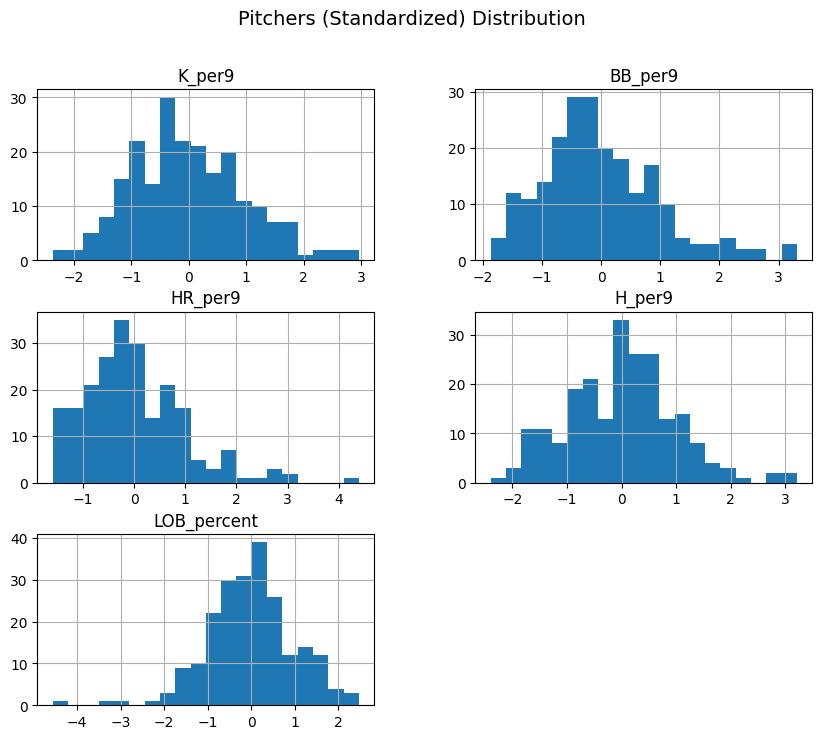

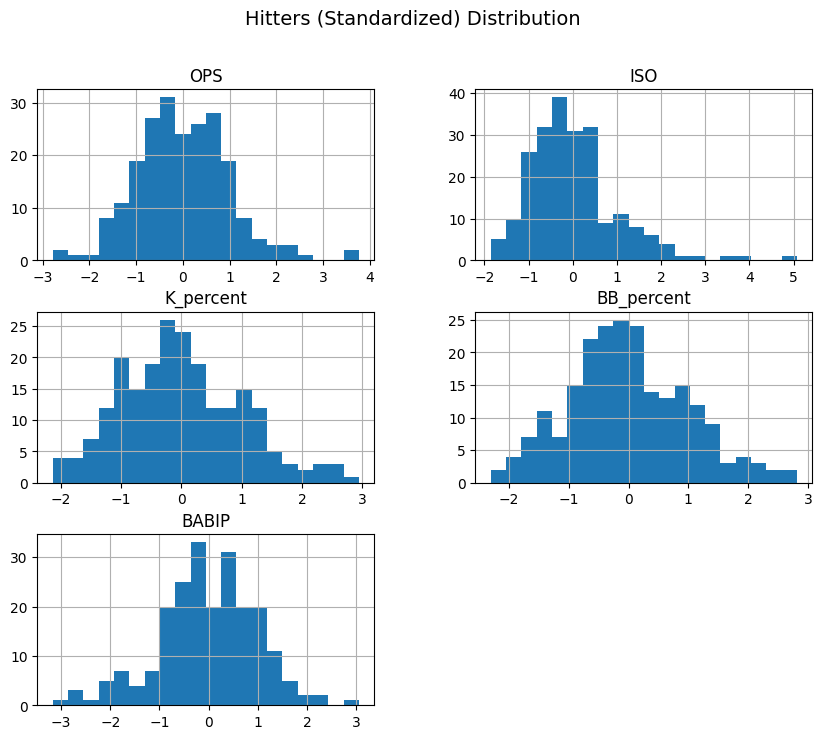

In [18]:
# Section 5

# 표준화 작업
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# NPB 투수 지표 표준화
pitcher_features_npb = ['K_per9','BB_per9','HR_per9','H_per9','LOB_percent']
scaler_pitchers_npb = StandardScaler()
pitchers_npb_scaled = scaler_pitchers_npb.fit_transform(pitchers_npb_filtered[pitcher_features_npb])

# NPB 타자 지표 표준화
hitter_features_npb = ['OPS','ISO','K_percent','BB_percent','BABIP']
scaler_hitters_npb = StandardScaler()
hitters_npb_scaled = scaler_hitters_npb.fit_transform(hitters_npb_filtered[hitter_features_npb])

pitchers_scaled_df_npb = pd.DataFrame(pitchers_npb_scaled, columns=pitcher_features_npb)
hitters_scaled_df_npb = pd.DataFrame(hitters_npb_scaled, columns=hitter_features_npb)

# 투수 분포 시각화
pitchers_scaled_df_npb.hist(figsize=(10, 8), bins=20)
plt.suptitle("Pitchers (Standardized) Distribution", fontsize=14)
plt.show()

# 타자 분포 시각화
hitters_scaled_df_npb.hist(figsize=(10, 8), bins=20)
plt.suptitle("Hitters (Standardized) Distribution", fontsize=14)
plt.show()

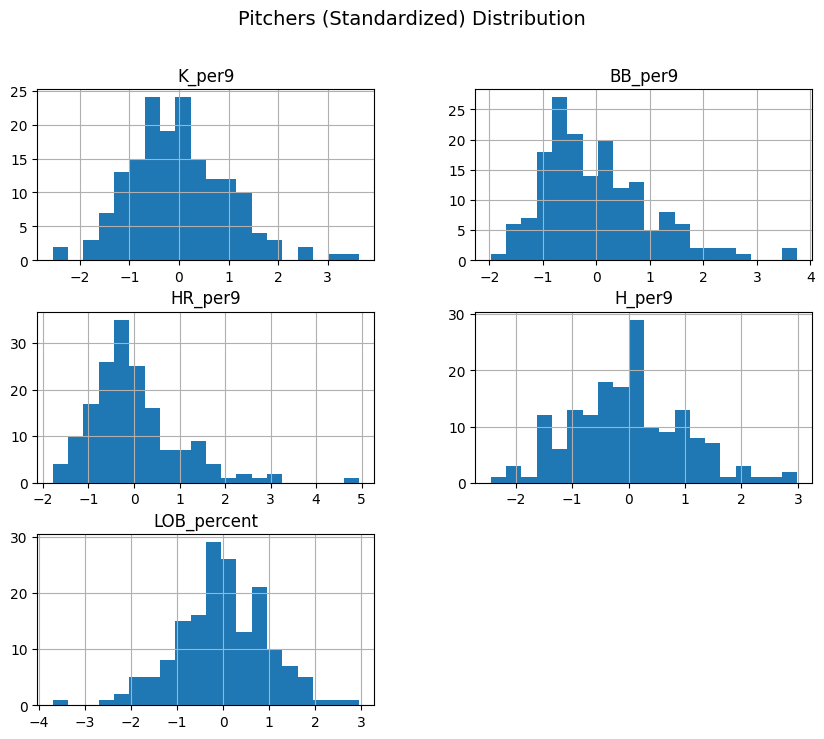

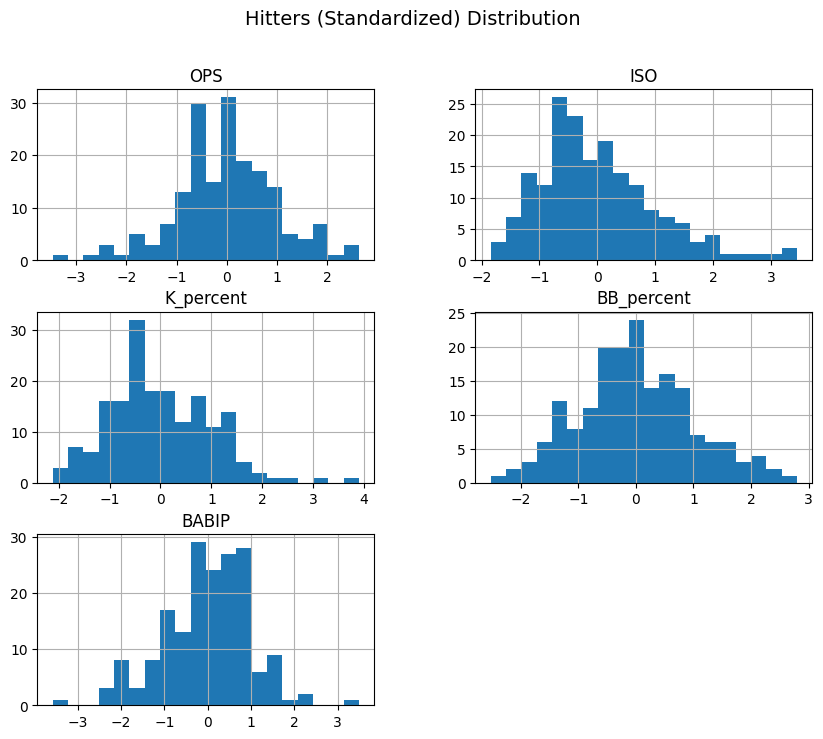

In [17]:
# Section 6

# 표준화 작업
from sklearn.preprocessing import StandardScaler

# KBO 투수 지표 표준화
pitcher_features_kbo = ['K_per9','BB_per9','HR_per9','H_per9','LOB_percent']
scaler_pitchers_kbo = StandardScaler()
pitchers_kbo_scaled = scaler_pitchers_kbo.fit_transform(pitchers_kbo_filtered[pitcher_features_kbo])

# KBO 타자 지표 표준화
hitter_features_kbo = ['OPS','ISO','K_percent','BB_percent','BABIP']
scaler_hitters_kbo = StandardScaler()
hitters_kbo_scaled = scaler_hitters_kbo.fit_transform(hitters_kbo_filtered[hitter_features_kbo])

# 표준화된 값 → DataFrame으로 변환
pitchers_scaled_df_kbo = pd.DataFrame(pitchers_kbo_scaled, columns=pitcher_features_kbo)
hitters_scaled_df_kbo = pd.DataFrame(hitters_kbo_scaled, columns=hitter_features_kbo)

# 투수 분포 시각화
pitchers_scaled_df_kbo.hist(figsize=(10, 8), bins=20)
plt.suptitle("Pitchers (Standardized) Distribution", fontsize=14)
plt.show()

# 타자 분포 시각화
hitters_scaled_df_kbo.hist(figsize=(10, 8), bins=20)
plt.suptitle("Hitters (Standardized) Distribution", fontsize=14)
plt.show()


Pitchers results:
k=2, inertia=582.666, silhouette=0.242
k=3, inertia=490.150, silhouette=0.209
k=4, inertia=457.209, silhouette=0.166
k=5, inertia=411.898, silhouette=0.156
k=6, inertia=378.103, silhouette=0.164
Hitters results:
k=2, inertia=602.598, silhouette=0.226
k=3, inertia=519.963, silhouette=0.192
k=4, inertia=453.099, silhouette=0.189
k=5, inertia=393.090, silhouette=0.190
k=6, inertia=356.071, silhouette=0.197


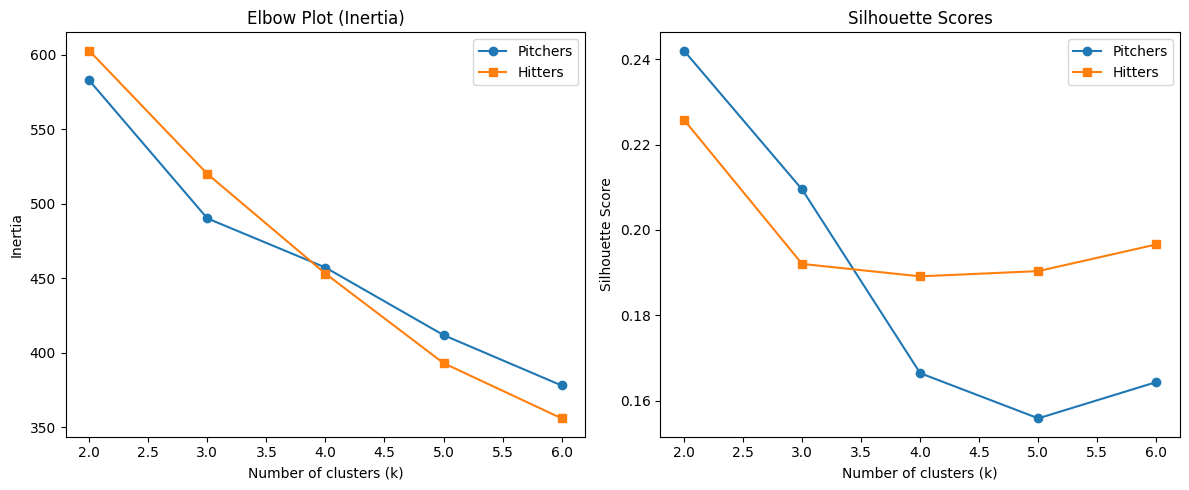

In [19]:
# Section 7

# 이상치 제거
def remove_outliers_iqr(df):
    cleaned_df = df.copy()
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        cleaned_df = cleaned_df[(cleaned_df[col] >= lower_bound) & (cleaned_df[col] <= upper_bound)]
    return cleaned_df

pitchers_no_outliers_npb = remove_outliers_iqr(pitchers_scaled_df_npb)
hitters_no_outliers_npb = remove_outliers_iqr(hitters_scaled_df_npb)

# 최적의 k를 탐색
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 7)

# 투수
X_pitch_npb = pitchers_no_outliers_npb
inertias_pitch, silhouettes_pitch = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(X_pitch_npb)
    inertias_pitch.append(km.inertia_)
    silhouettes_pitch.append(silhouette_score(X_pitch_npb, km.labels_))

print("\nPitchers results:")
for i, k in enumerate(ks):
    print(f"k={k}, inertia={inertias_pitch[i]:.3f}, silhouette={silhouettes_pitch[i]:.3f}")

# 타자
X_hit_npb = hitters_no_outliers_npb
inertias_hit, silhouettes_hit = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(X_hit_npb)
    inertias_hit.append(km.inertia_)
    silhouettes_hit.append(silhouette_score(X_hit_npb, km.labels_))

print("Hitters results:")
for i, k in enumerate(ks):
    print(f"k={k}, inertia={inertias_hit[i]:.3f}, silhouette={silhouettes_hit[i]:.3f}")


# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Elbow plot
axes[0].plot(list(ks), inertias_pitch, marker='o', label='Pitchers')
axes[0].plot(list(ks), inertias_hit, marker='s', label='Hitters')
axes[0].set_title("Elbow Plot (Inertia)")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].legend()

# Silhouette plot
axes[1].plot(list(ks), silhouettes_pitch, marker='o', label='Pitchers')
axes[1].plot(list(ks), silhouettes_hit, marker='s', label='Hitters')
axes[1].set_title("Silhouette Scores")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()

plt.tight_layout()
plt.show()


Pitchers results:
k=2, inertia=410.438, silhouette=0.222
k=3, inertia=362.528, silhouette=0.155
k=4, inertia=325.923, silhouette=0.157
k=5, inertia=288.546, silhouette=0.174
k=6, inertia=264.447, silhouette=0.181
Hitters results:
k=2, inertia=489.126, silhouette=0.239
k=3, inertia=407.805, silhouette=0.218
k=4, inertia=357.567, silhouette=0.204
k=5, inertia=316.659, silhouette=0.205
k=6, inertia=284.748, silhouette=0.211


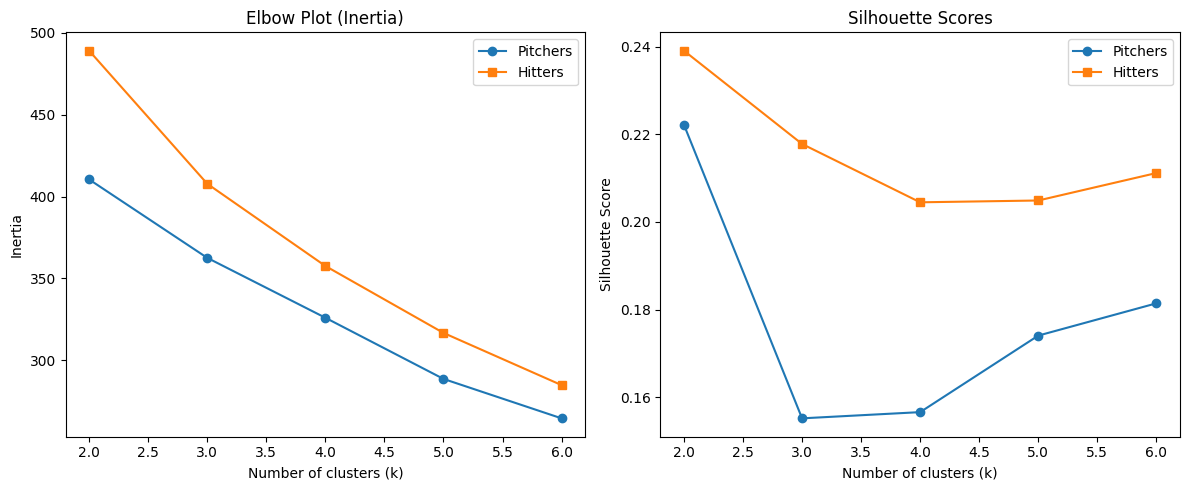

In [21]:
# Section 8

# 이상치 제거
def remove_outliers_iqr(df):
    cleaned_df = df.copy()
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        cleaned_df = cleaned_df[(cleaned_df[col] >= lower_bound) & (cleaned_df[col] <= upper_bound)]
    return cleaned_df

pitchers_no_outliers_kbo = remove_outliers_iqr(pitchers_scaled_df_kbo)
hitters_no_outliers_kbo = remove_outliers_iqr(hitters_scaled_df_kbo)

# 최적의 k를 탐색
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 7)

# 투수
X_pitch_kbo = pitchers_no_outliers_kbo
inertias_pitch, silhouettes_pitch = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(X_pitch_kbo)
    inertias_pitch.append(km.inertia_)
    silhouettes_pitch.append(silhouette_score(X_pitch_kbo, km.labels_))

print("\nPitchers results:")
for i, k in enumerate(ks):
    print(f"k={k}, inertia={inertias_pitch[i]:.3f}, silhouette={silhouettes_pitch[i]:.3f}")

# 타자
X_hit_kbo = hitters_no_outliers_kbo
inertias_hit, silhouettes_hit = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(X_hit_kbo)
    inertias_hit.append(km.inertia_)
    silhouettes_hit.append(silhouette_score(X_hit_kbo, km.labels_))

print("Hitters results:")
for i, k in enumerate(ks):
    print(f"k={k}, inertia={inertias_hit[i]:.3f}, silhouette={silhouettes_hit[i]:.3f}")


# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Elbow plot
axes[0].plot(list(ks), inertias_pitch, marker='o', label='Pitchers')
axes[0].plot(list(ks), inertias_hit, marker='s', label='Hitters')
axes[0].set_title("Elbow Plot (Inertia)")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].legend()

# Silhouette plot
axes[1].plot(list(ks), silhouettes_pitch, marker='o', label='Pitchers')
axes[1].plot(list(ks), silhouettes_hit, marker='s', label='Hitters')
axes[1].set_title("Silhouette Scores")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()

plt.tight_layout()
plt.show()

Pitchers best params: (np.float64(1.8000000000000005), 2) score: 0.2318136578468645

Hitters best params: (np.float64(1.3000000000000003), 2) score: 0.22748846114605278


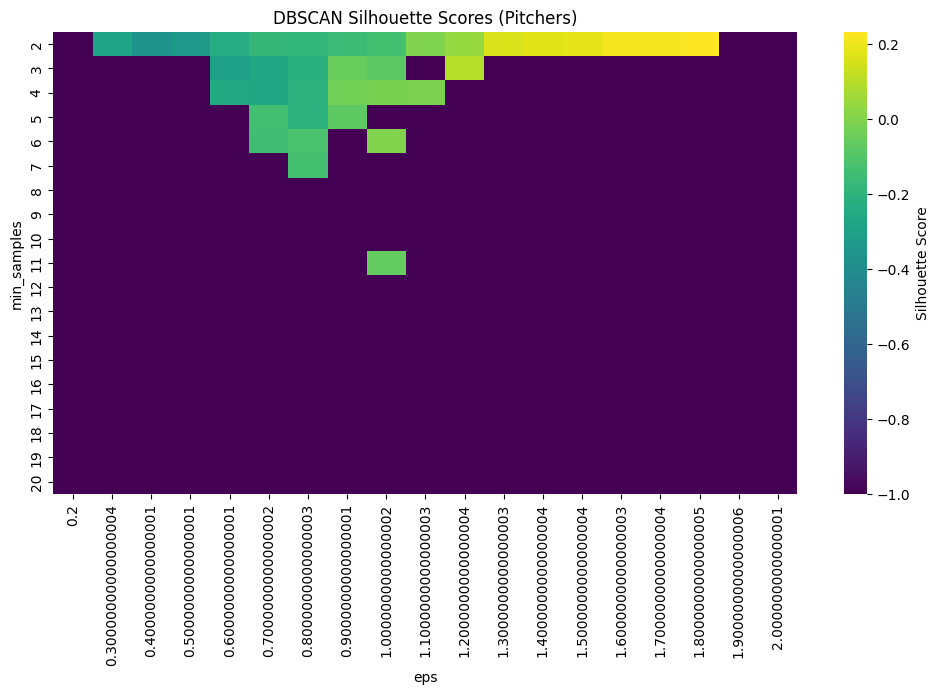

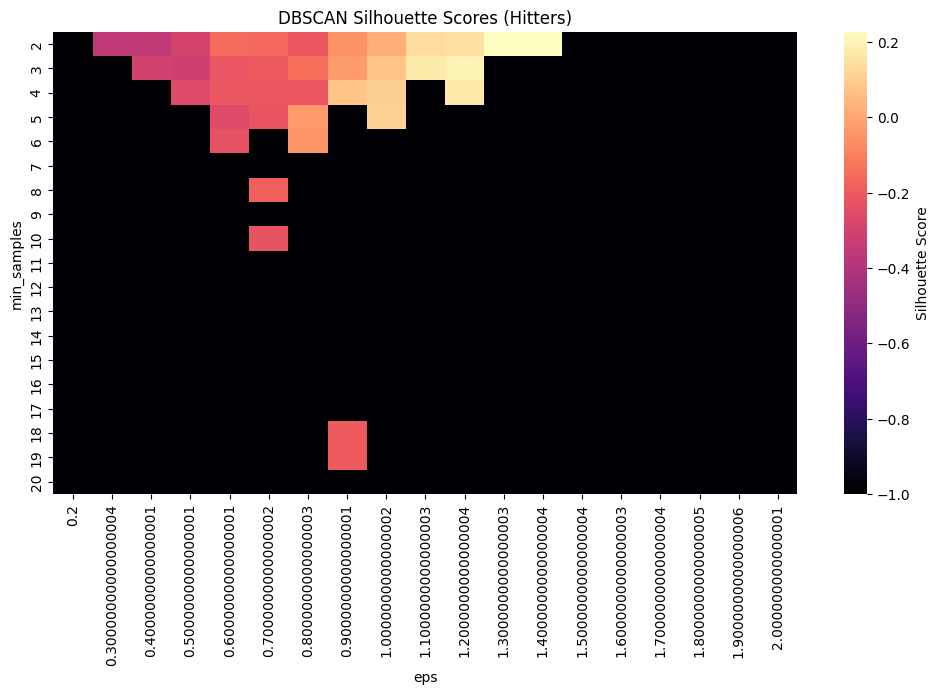

In [24]:
# Section 9

# NPB DBSCAN 분석
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

# 후보값 설정
eps_values = np.arange(0.2, 2.1, 0.1)
min_samples_values = range(2, 21)

def find_best_dbscan(X, eps_values, min_samples_values):
    best_score = -1
    best_params = None
    results = []

    for eps in eps_values:
        for min_samples in min_samples_values:
            db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
            labels = db.labels_
            unique_labels = set(labels)

            # silhouette 계산 조건: 군집이 2개 이상 존재해야 함
            if len(unique_labels - {-1}) > 1:
                score = silhouette_score(X, labels)
            else:
                score = -1

            results.append((eps, min_samples, score, unique_labels))

            if score > best_score:
                best_score = score
                best_params = (eps, min_samples)

    return best_params, best_score, results

# 투수 데이터
best_pitch_params, best_pitch_score, pitch_results_npb = find_best_dbscan(pitchers_no_outliers_npb, eps_values, min_samples_values)
print("Pitchers best params:", best_pitch_params, "score:", best_pitch_score)

# 타자 데이터
best_hit_params, best_hit_score, hit_results_npb = find_best_dbscan(hitters_no_outliers_npb, eps_values, min_samples_values)
print("\nHitters best params:", best_hit_params, "score:", best_hit_score)


# 시각화

import seaborn as sns

# Dataframe화
pitch_df_npb = pd.DataFrame(pitch_results_npb, columns=["eps", "min_samples", "score", "labels"])
hit_df_npb = pd.DataFrame(hit_results_npb, columns=["eps", "min_samples", "score", "labels"])

# 투수
plt.figure(figsize=(12, 6))
pivot_pitch = pitch_df_npb.pivot(index="min_samples", columns="eps", values="score")
sns.heatmap(pivot_pitch, cmap="viridis", annot=False, cbar_kws={'label': 'Silhouette Score'})
plt.title("DBSCAN Silhouette Scores (Pitchers)")
plt.xlabel("eps")
plt.ylabel("min_samples")
plt.show()

# 타자
plt.figure(figsize=(12, 6))
pivot_hit = hit_df_npb.pivot(index="min_samples", columns="eps", values="score")
sns.heatmap(pivot_hit, cmap="magma", annot=False, cbar_kws={'label': 'Silhouette Score'})
plt.title("DBSCAN Silhouette Scores (Hitters)")
plt.xlabel("eps")
plt.ylabel("min_samples")
plt.show()

Pitchers best params: (np.float64(1.5000000000000004), 2) score: 0.19422568324651268

Hitters best params: (np.float64(1.1000000000000003), 4) score: 0.13952369489753183


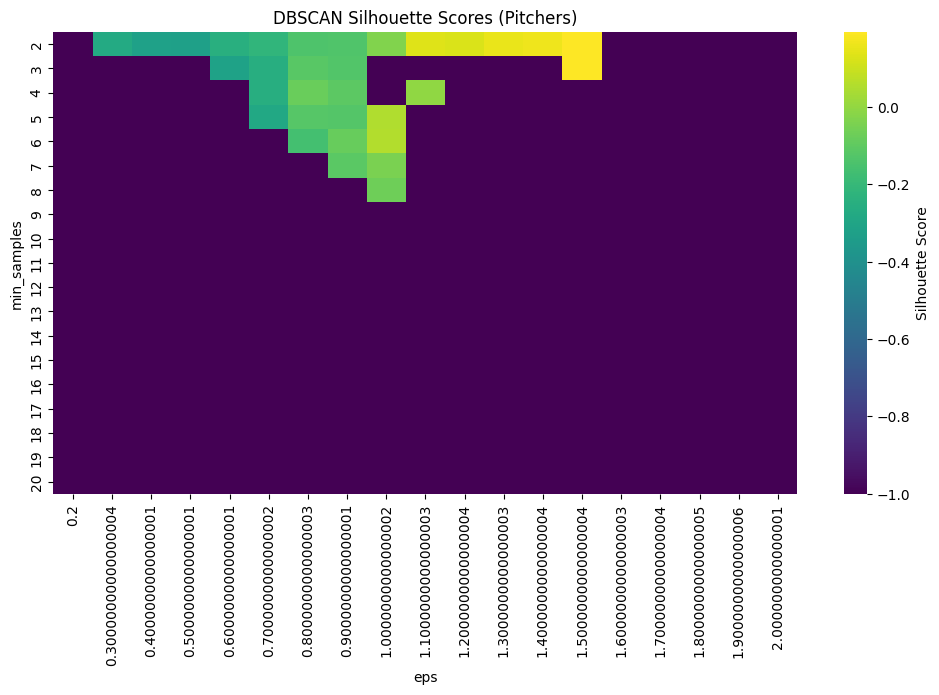

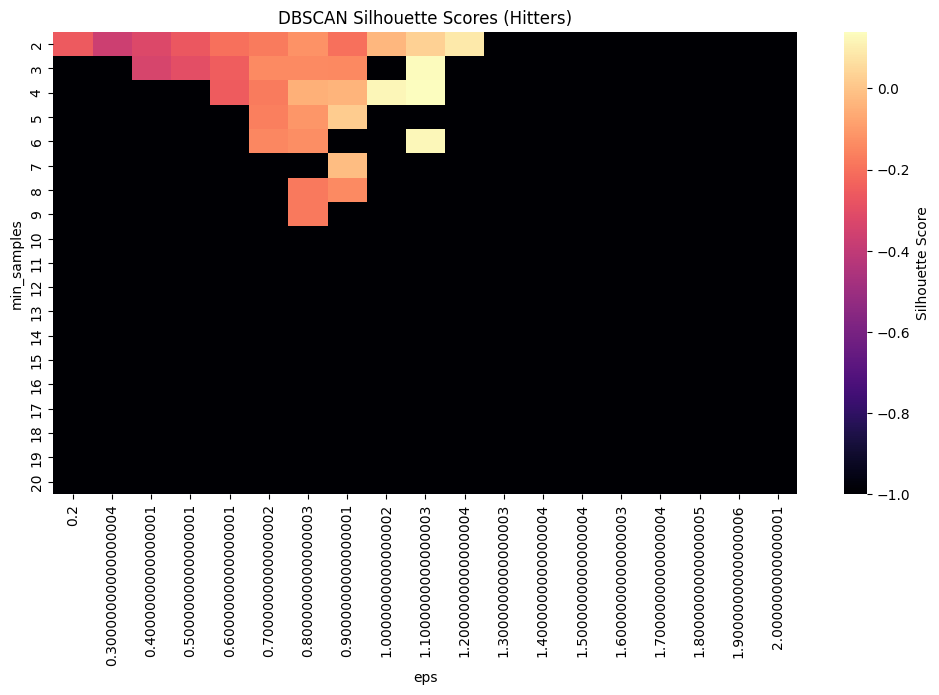

In [25]:
# Section 10

# KBO DBSCAN 분석
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

# 후보값 설정
eps_values = np.arange(0.2, 2.1, 0.1)
min_samples_values = range(2, 21)

def find_best_dbscan(X, eps_values, min_samples_values):
    best_score = -1
    best_params = None
    results = []

    for eps in eps_values:
        for min_samples in min_samples_values:
            db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
            labels = db.labels_
            unique_labels = set(labels)

            # silhouette 계산 조건: 군집이 2개 이상 존재해야 함
            if len(unique_labels - {-1}) > 1:
                score = silhouette_score(X, labels)
            else:
                score = -1

            results.append((eps, min_samples, score, unique_labels))

            if score > best_score:
                best_score = score
                best_params = (eps, min_samples)

    return best_params, best_score, results

# 투수 데이터
best_pitch_params, best_pitch_score, pitch_results_kbo = find_best_dbscan(pitchers_no_outliers_kbo, eps_values, min_samples_values)
print("Pitchers best params:", best_pitch_params, "score:", best_pitch_score)

# 타자 데이터
best_hit_params, best_hit_score, hit_results_kbo = find_best_dbscan(hitters_no_outliers_kbo, eps_values, min_samples_values)
print("\nHitters best params:", best_hit_params, "score:", best_hit_score)

import seaborn as sns

# Dataframe화
pitch_df_kbo = pd.DataFrame(pitch_results_kbo, columns=["eps", "min_samples", "score", "labels"])
hit_df_kbo = pd.DataFrame(hit_results_kbo, columns=["eps", "min_samples", "score", "labels"])

# 투수
plt.figure(figsize=(12, 6))
pivot_pitch = pitch_df_kbo.pivot(index="min_samples", columns="eps", values="score")
sns.heatmap(pivot_pitch, cmap="viridis", annot=False, cbar_kws={'label': 'Silhouette Score'})
plt.title("DBSCAN Silhouette Scores (Pitchers)")
plt.xlabel("eps")
plt.ylabel("min_samples")
plt.show()

# 타자
plt.figure(figsize=(12, 6))
pivot_hit = hit_df_kbo.pivot(index="min_samples", columns="eps", values="score")
sns.heatmap(pivot_hit, cmap="magma", annot=False, cbar_kws={'label': 'Silhouette Score'})
plt.title("DBSCAN Silhouette Scores (Hitters)")
plt.xlabel("eps")
plt.ylabel("min_samples")
plt.show()

두번의 군집화 시도 모두 실패하였다.
이것은 데이터가 특정한 곳에 모여있지 않고, 전체적으로 퍼진, 연속형이라는 것을 의미한다.
따라서 마지막 방법으로, 데이터의 주요 변동 방향을 찾아 차원을 축소하는 기법인 PCA를 활용해 최소한의 패턴을 찾아보기로 했다.

Explained variance ratio: [0.39113546 0.2107609 ]
PC1 loadings: [-0.52772326 -0.12930221  0.26270207  0.6032661  -0.52138923]
PC2 loadings: [ 0.24200033  0.78745292 -0.3625649   0.20687717 -0.38353914]


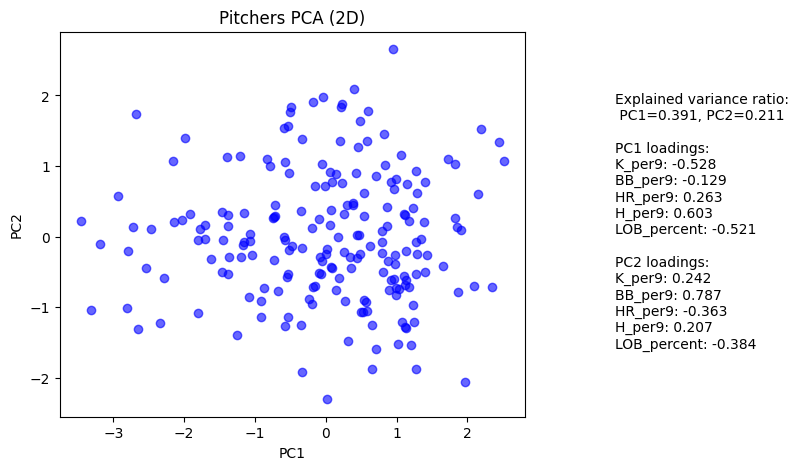

Explained variance ratio: [0.37768618 0.24967196]
PC1 loadings: [ 0.67332409  0.41644419 -0.25982567  0.38381441  0.39797743]
PC2 loadings: [0.00205723 0.24493551 0.92989689 0.09212297 0.25847147]


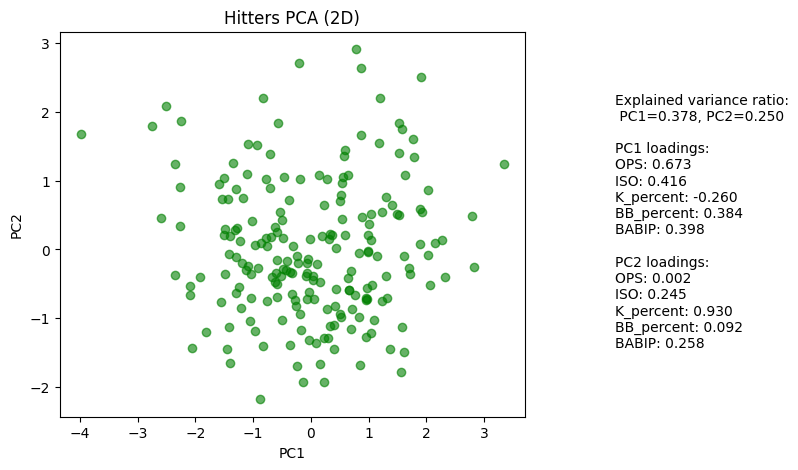

In [26]:
# Section 11

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 투수 데이터 PCA
pitcher_features_npb = ['K_per9','BB_per9','HR_per9','H_per9','LOB_percent']
pca_pitch = PCA(n_components=2)
pitch_2d = pca_pitch.fit_transform(pitchers_no_outliers_npb)
pca = PCA(n_components=2)

pca.fit(pitchers_no_outliers_npb)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("PC1 loadings:", pca.components_[0])
print("PC2 loadings:", pca.components_[1])

plt.figure(figsize=(6, 5))
plt.scatter(pitch_2d[:, 0], pitch_2d[:, 1], alpha=0.6, color="blue")
plt.title("Pitchers PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
textstr = (f"Explained variance ratio:\n PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}\n\n"
           f"PC1 loadings:\n" + "\n".join([f"{f}: {l:.3f}" for f, l in zip(pitcher_features_npb, pca.components_[0])]) + "\n\n"
           f"PC2 loadings:\n" + "\n".join([f"{f}: {l:.3f}" for f, l in zip(pitcher_features_npb, pca.components_[1])]))

plt.gcf().text(1.05, 0.5, textstr, fontsize=10, va="center")
plt.show()

# 타자 데이터 PCA
hitter_features_npb = ['OPS','ISO','K_percent','BB_percent','BABIP']
pca_hit = PCA(n_components=2)
hit_2d = pca_hit.fit_transform(hitters_no_outliers_npb)

pca.fit(hitters_no_outliers_npb)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("PC1 loadings:", pca.components_[0])
print("PC2 loadings:", pca.components_[1])

plt.figure(figsize=(6, 5))
plt.scatter(hit_2d[:, 0], hit_2d[:, 1], alpha=0.6, color="green")
plt.title("Hitters PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
textstr = (f"Explained variance ratio:\n PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}\n\n"
           f"PC1 loadings:\n" + "\n".join([f"{f}: {l:.3f}" for f, l in zip(hitter_features_npb, pca.components_[0])]) + "\n\n"
           f"PC2 loadings:\n" + "\n".join([f"{f}: {l:.3f}" for f, l in zip(hitter_features_npb, pca.components_[1])]))

plt.gcf().text(1.05, 0.5, textstr, fontsize=10, va="center")
plt.show()

Explained variance ratio: [0.37742402 0.2242872 ]
PC1 loadings: [-0.46642491  0.03080592  0.42278419  0.6264814  -0.45855576]
PC2 loadings: [ 0.51084017  0.80285218  0.13421062  0.05141303 -0.27168898]


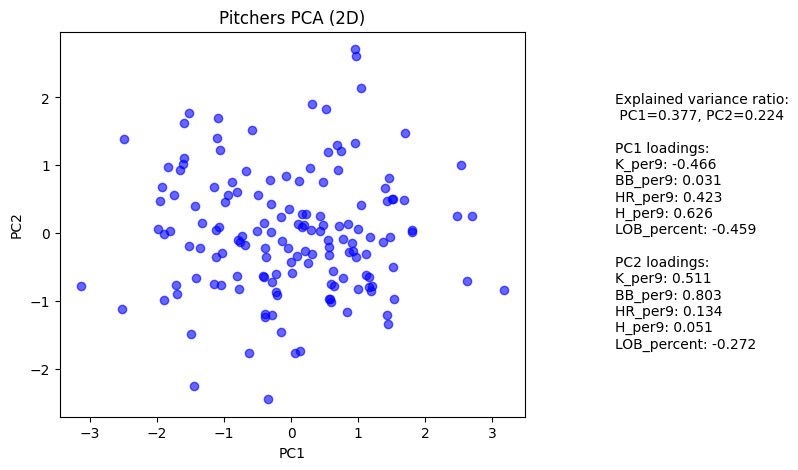

Explained variance ratio: [0.40397026 0.24572296]
PC1 loadings: [ 0.65141707  0.44962219 -0.20568159  0.41335893  0.40040625]
PC2 loadings: [-0.12179071 -0.10550702 -0.36054964  0.7017066  -0.5929984 ]


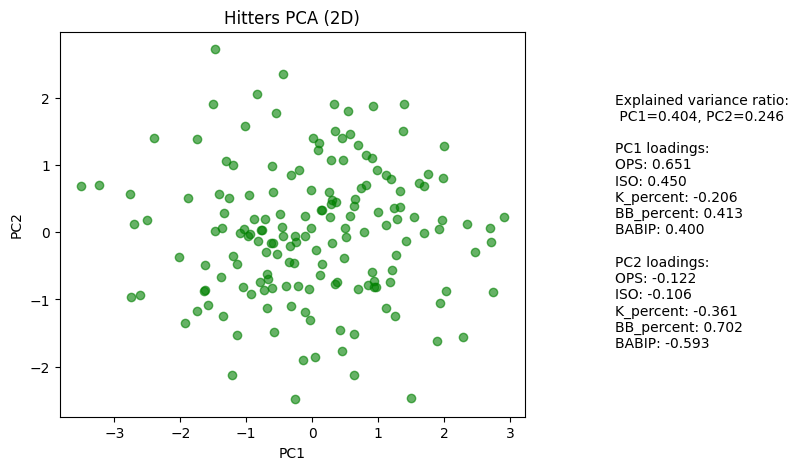

In [27]:
# Section 12

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 투수 데이터 PCA
pitcher_features_kbo = ['K_per9','BB_per9','HR_per9','H_per9','LOB_percent']
pca_pitch = PCA(n_components=2)
pitch_2d = pca_pitch.fit_transform(pitchers_no_outliers_kbo)
pca = PCA(n_components=2)

pca.fit(pitchers_no_outliers_kbo)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("PC1 loadings:", pca.components_[0])
print("PC2 loadings:", pca.components_[1])

plt.figure(figsize=(6, 5))
plt.scatter(pitch_2d[:, 0], pitch_2d[:, 1], alpha=0.6, color="blue")
plt.title("Pitchers PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
textstr = (f"Explained variance ratio:\n PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}\n\n"
           f"PC1 loadings:\n" + "\n".join([f"{f}: {l:.3f}" for f, l in zip(pitcher_features_kbo, pca.components_[0])]) + "\n\n"
           f"PC2 loadings:\n" + "\n".join([f"{f}: {l:.3f}" for f, l in zip(pitcher_features_kbo, pca.components_[1])]))
plt.gcf().text(1.05, 0.5, textstr, fontsize=10, va="center")
plt.show()

# 타자 데이터 PCA
hitter_features_kbo = ['OPS','ISO','K_percent','BB_percent','BABIP']
pca_hit = PCA(n_components=2)
hit_2d = pca_hit.fit_transform(hitters_no_outliers_kbo)

pca.fit(hitters_no_outliers_kbo)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("PC1 loadings:", pca.components_[0])
print("PC2 loadings:", pca.components_[1])

plt.figure(figsize=(6, 5))
plt.scatter(hit_2d[:, 0], hit_2d[:, 1], alpha=0.6, color="green")
plt.title("Hitters PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
textstr = (f"Explained variance ratio:\n PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}\n\n"
           f"PC1 loadings:\n" + "\n".join([f"{f}: {l:.3f}" for f, l in zip(hitter_features_kbo, pca.components_[0])]) + "\n\n"
           f"PC2 loadings:\n" + "\n".join([f"{f}: {l:.3f}" for f, l in zip(hitter_features_kbo, pca.components_[1])]))
plt.gcf().text(1.05, 0.5, textstr, fontsize=10, va="center")
plt.show()